In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# === 1. Define paths and optimisers ===
data_dir = "Data/Mix/"  # adjust if needed
optimisers = {
    "MC": "MC_Data_FullResults_*_*.csv",
    "GA": "Evo_Data_FullResults_*_*.csv",
    "RL": "RL_Data_FullResults_*_*.csv"
}

# === 2. Helper: load and clean individual files ===
def load_one_file(filepath, optimiser):
    df = pd.read_csv(filepath)
    filename = os.path.basename(filepath)

    # Extract dataset name (e.g., EnglishMale, GermanMale)
    dataset = filename.split("_")[-1].replace(".csv", "")

    # --- Special handling for GA ---
    if optimiser == "GA":
        if "score" in df.columns:
            df = df[df["score"] != 0]          # remove zero scores
            if len(df) > 60:                   # remove last 60 if overrun
                df = df.iloc[:-60, :]
        else:
            raise ValueError(f"GA file missing 'score' column: {filename}")
    if optimiser == "RL" :
        df.drop(columns=["update", "episode", "timestep"], errors="ignore")
        df.drop(columns=["update", "episode", "timestep"], errors="ignore")


    # --- General cleaning for all optimisers ---
    df = df.drop_duplicates()

    # --- Select correct metric ---
    if "score" in df.columns:
        value_col = "score"
    elif "reward" in df.columns:
        value_col = "reward"
    else:
        raise ValueError(f"No valid 'score' or 'reward' column in {filename}")

    # --- Label and return ---
    df["Optimiser"] = optimiser
    df["Dataset"] = dataset
    df["Value"] = df[value_col]
    return df[["Optimiser", "Dataset", "Value"]]

# === 3. Load all datasets automatically ===
all_dfs = []
for opt, pattern in optimisers.items():
    for filepath in glob.glob(os.path.join(data_dir, pattern)):
        try:
            all_dfs.append(load_one_file(filepath, opt))
        except Exception as e:
            print(f"⚠️ Skipped {filepath}: {e}")

df_all = pd.concat(all_dfs, ignore_index=True)



/tmp/ipykernel_161239/1841111388.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["Optimiser", "Dataset"], group_keys=False).apply(


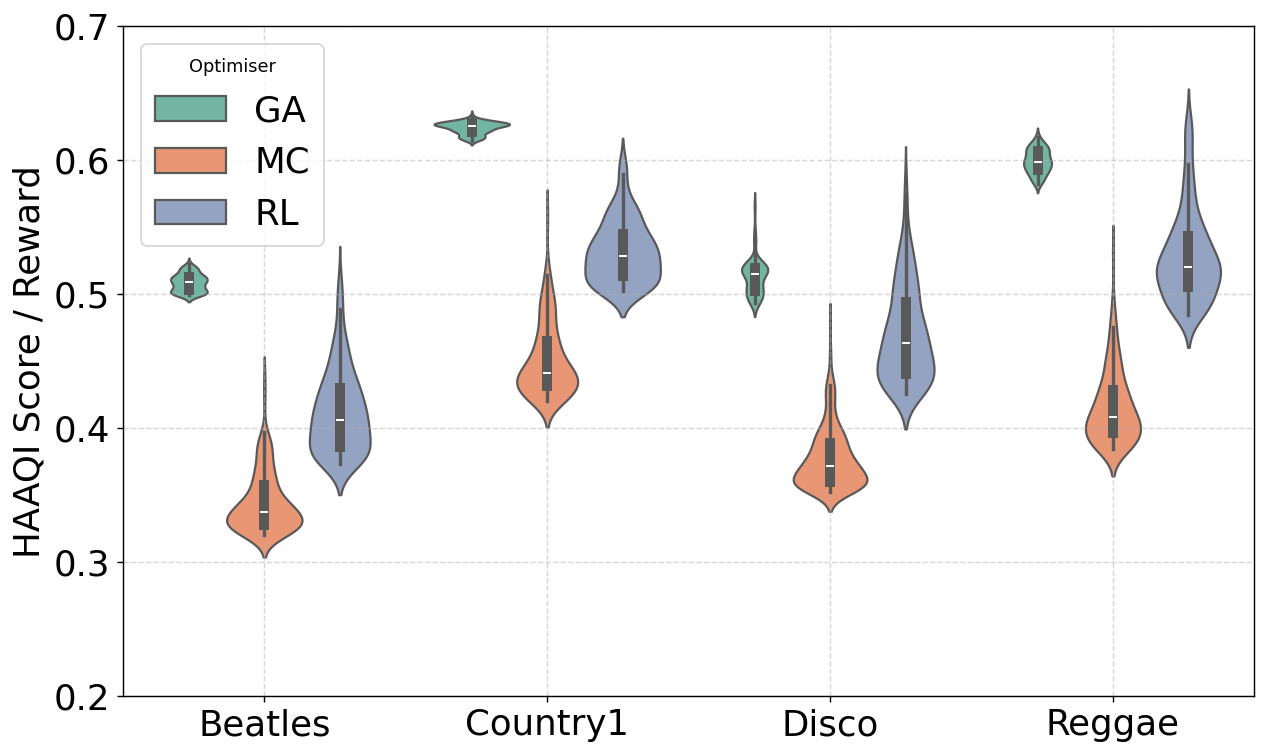

                      mean  median     std     cv
Dataset  Optimiser                               
Beatles  GA         0.5084  0.5090  0.0065  0.013
         MC         0.3445  0.3369  0.0223  0.065
         RL         0.4125  0.4062  0.0312  0.076
Country1 GA         0.6241  0.6254  0.0044  0.007
         MC         0.4507  0.4413  0.0266  0.059
         RL         0.5319  0.5286  0.0231  0.043
Disco    GA         0.5128  0.5148  0.0132  0.026
         MC         0.3771  0.3712  0.0226  0.060
         RL         0.4700  0.4632  0.0355  0.076
Reggae   GA         0.5993  0.5989  0.0089  0.015
         MC         0.4159  0.4078  0.0273  0.066
         RL         0.5284  0.5204  0.0338  0.064


In [3]:
# === 4. Optional: keep only top 5% per optimiser/dataset ===
def top_fraction_per_group(df, frac=0.10):
    return df.groupby(["Optimiser", "Dataset"], group_keys=False).apply(
        lambda g: g[g["Value"] >= g["Value"].quantile(1 - frac)]
    )

df_top = top_fraction_per_group(df_all, frac=0.25)

# === 5. Plot grouped boxplots ===
plt.figure(figsize=(10,6),dpi=128)
#sns.boxplot(data=df_top, x="Dataset", y="Value", hue="Optimiser", palette="Set2")
sns.violinplot(data=df_top, x="Dataset", y="Value", hue="Optimiser", palette="Set2")
#plt.title("Top 25% Optimisation Performance Across Datasets and Methods")
plt.ylabel("HAAQI Score / Reward", fontsize=20)
plt.ylim(0.20, 0.70)
plt.xlabel("", fontsize=24)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(title="Optimiser", fontsize=20)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# === 6. Summary stats ===
summary = df_top.groupby(["Dataset", "Optimiser"])["Value"].agg(["mean", "median", "std"]).round(4)
summary["cv"] = (summary["std"] / summary["mean"]).round(3)
print(summary)